# 실전 프로젝트 2: AI 논문 리서치 팀 (Supervisor Workflow) - Phase 1

이 노트북에서는 다중 에이전트(Multi-Agent)가 협업하는 **팀장(Supervisor) 워크플로우**를 LangGraph로 구축합니다.
팀장, 연구원, 요약가, 번역가, 검수자가 각각의 역할을 맡아 하나의 상태(State)를 주고받으며 논문을 검색, 요약, 번역하고 품질을 검수합니다.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from typing import TypedDict, Optional
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END

## 1. 상태(State) 정의
에이전트들이 서로 주고받을 공통 메모리(State) 구조를 정의합니다.

In [2]:
class TeamState(TypedDict):
    question: str                  # 사용자의 질문/지시사항
    next_node: str                 # 다음에 실행될 에이전트 (라우팅용)
    raw_paper_content: str         # 검색된 논문 영어 원문
    summarized_content: str        # 핵심 요약본 (영어)
    korean_translation: str        # 한글 번역본
    critic_feedback: str           # 검수자의 피드백 (반려 시)
    revision_count: int            # 재번역 횟수

## 2. LLM 초기화 및 각 노드(Node) 함수 정의

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini")

# 1. 팀장 (Supervisor)
def supervisor_node(state: TeamState):
    print(f"\n👨‍💼 [Supervisor] 업무 분배 중... (요청: '{state['question']}')")
    # 프로토타입: 무조건 researcher -> summarizer -> translator -> critic 순으로 가도록 우선 설정
    # 실제로는 LLM에게 "다음에 누구한테 시킬까?" 물어볼 수 있지만, 파이프라인이 명확하므로 하드코딩 라우팅도 가능합니다.
    # 여기서는 첫 진입점 역할을 합니다.
    if not state.get("raw_paper_content"):
        return {"next_node": "researcher"}
    else:
        return {"next_node": "summarizer"}

# 2. 연구원 (Researcher)
def researcher_node(state: TeamState):
    print("🔍 [Researcher] 논문 검색 중...")
    # Phase 1 하드코딩 모의 데이터 (Phase 3에서 실제 PDF/ArXiv 연동)
    mock_paper = """
    Title: Attention Is All You Need
    Abstract: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. 
    The best performing models also connect the encoder and decoder through an attention mechanism. 
    We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely.
    Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train.
    """
    return {"raw_paper_content": mock_paper.strip()}

# 3. 요약가 (Summarizer)
def summarizer_node(state: TeamState):
    print("✍️ [Summarizer] 원문 요약 중...")
    prompt = ChatPromptTemplate.from_template(
        "You are an expert academic summarizer. Summarize the following paper abstract into exactly 2 bullet points in English.\n\nPaper: {paper}"
    )
    summary = (prompt | llm).invoke({"paper": state["raw_paper_content"]}).content
    return {"summarized_content": summary}

# 4. 번역가 (Translator)
def translator_node(state: TeamState):
    print("🌐 [Translator] 한글 번역 중...")
    feedback = state.get("critic_feedback", "")
    feedback_msg = f"\n\n[이전 번역에 대한 팀장의 지적사항]\n{feedback}\n이 지적사항을 반드시 반영해서 다시 번역해!" if feedback else ""
    
    prompt = ChatPromptTemplate.from_template(
        "당신은 전문 학술 번역가입니다. 다음 영어 요약본을 자연스러운 한국어로 번역하세요.{feedback_msg}\n\n영어 원문: {summary}"
    )
    translation = (prompt | llm).invoke({"summary": state["summarized_content"], "feedback_msg": feedback_msg}).content
    
    count = state.get("revision_count", 0) + 1
    return {"korean_translation": translation, "revision_count": count}

# 5. 검수자 (Critic)
def critic_node(state: TeamState):
    print("🧐 [Critic] 번역 퀄리티 검수 중...")
    # 프로토타입용 강제 빠꾸 로직: 1번째 번역이면 무조건 핑계를 대고 다시 번역하게 만듦 (Reflexion 테스트용)
    if state.get("revision_count", 1) < 2:
        print("   -> ❌ [반려] 번역이 너무 직역투입니다. 전문 용어를 더 살려주세요.")
        return {"critic_feedback": "번역이 너무 직역투입니다. 'attention' 같은 단어는 문맥에 맞게 번역하고, 학술적인 어투로 다듬어주세요."}
    else:
        print("   -> ✅ [통과] 번역 퀄리티가 좋습니다.")
        return {"critic_feedback": "PASS"}


## 3. 엣지(Edge) 라우팅 로직 정의

In [4]:
def route_after_supervisor(state: TeamState):
    return state["next_node"]

def route_after_critic(state: TeamState):
    if state["critic_feedback"] == "PASS":
        return "end"
    else:
        return "retry_translation"

## 4. Graph 조립 및 컴파일

In [5]:
workflow = StateGraph(TeamState)

# 노드 추가
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("researcher", researcher_node)
workflow.add_node("summarizer", summarizer_node)
workflow.add_node("translator", translator_node)
workflow.add_node("critic", critic_node)

# 진입점
workflow.set_entry_point("supervisor")

# 엣지 연결
workflow.add_conditional_edges(
    "supervisor",
    route_after_supervisor,
    {"researcher": "researcher", "summarizer": "summarizer"}
)
workflow.add_edge("researcher", "summarizer")
workflow.add_edge("summarizer", "translator")
workflow.add_edge("translator", "critic")

# Critic의 검수 결과에 따른 조건부 엣지 (무한 검증 루프)
workflow.add_conditional_edges(
    "critic",
    route_after_critic,
    {
        "retry_translation": "translator",  # 빠꾸 맞으면 다시 번역가에게
        "end": END                          # 통과하면 종료
    }
)

app = workflow.compile()

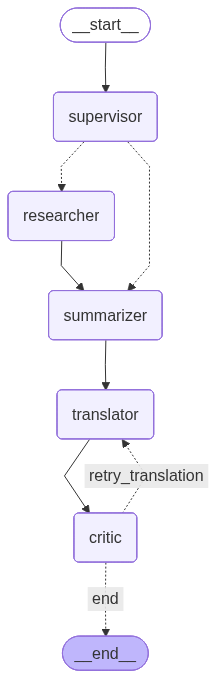

In [6]:
app

## 5. 실행 및 테스트

In [7]:
inputs = {"question": "최신 Transformer 논문 찾아서 번역해줘."}
result = app.invoke(inputs)

print("\n====================================")
print("🎉 [최종 완료] 번역 결과:")
print(result["korean_translation"])
print(f"\n(총 번역 횟수: {result['revision_count']}회)")
print("====================================")


👨‍💼 [Supervisor] 업무 분배 중... (요청: '최신 Transformer 논문 찾아서 번역해줘.')
🔍 [Researcher] 논문 검색 중...
✍️ [Summarizer] 원문 요약 중...
🌐 [Translator] 한글 번역 중...
🧐 [Critic] 번역 퀄리티 검수 중...
   -> ❌ [반려] 번역이 너무 직역투입니다. 전문 용어를 더 살려주세요.
🌐 [Translator] 한글 번역 중...
🧐 [Critic] 번역 퀄리티 검수 중...
   -> ✅ [통과] 번역 퀄리티가 좋습니다.

🎉 [최종 완료] 번역 결과:
이 논문은 전적으로 주의 메커니즘에 의존하는 새로운 신경망 구조인 Transformer를 소개합니다. 이는 시퀀스 변환 모델에서 순환 구조와 합성곱의 필요성을 제거합니다.  
기계 번역에 대한 실험 결과는 Transformer가 품질, 병렬 처리, 훈련 시간 효율성 측면에서 기존 모델보다 뛰어난 성능을 보임을 보여줍니다.

(총 번역 횟수: 2회)
